Install & Import Library

In [ ]:
!pip install imbalanced-learn scikit-learn joblib -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing Bengkod
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

# Evaluasi
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
# Imbalanced
from imblearn.over_sampling import SMOTE

# Save Model
import joblib

Load Dataset

In [ ]:
df_churn = pd.read_csv('Sales - Marketing customer dataset.csv')

print(f"Churn Dataset : {df_churn.shape[0]:,} baris, {df_churn.shape[1]} kolom")
print(df_churn.head())

Churn Dataset : 15,000 baris, 30 kolom
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_

## EDA

Info & Statistik Deskriptif

In [ ]:
# 5 baris pertama
print("=== 5 Baris Pertama ===")
df_churn.head()

# informasi dataset
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
df_churn.info()

# statistik deskriptif
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
df_churn.describe()

=== 5 Baris Pertama ===
INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


Missing Value

Kolom dengan Missing Value:
                    Jumlah Missing  Persentase (%)
coupon_code                   6133           40.89
age                           1200            8.00
total_spent                   1050            7.00
gender                         738            4.92
satisfaction_score             702            4.68


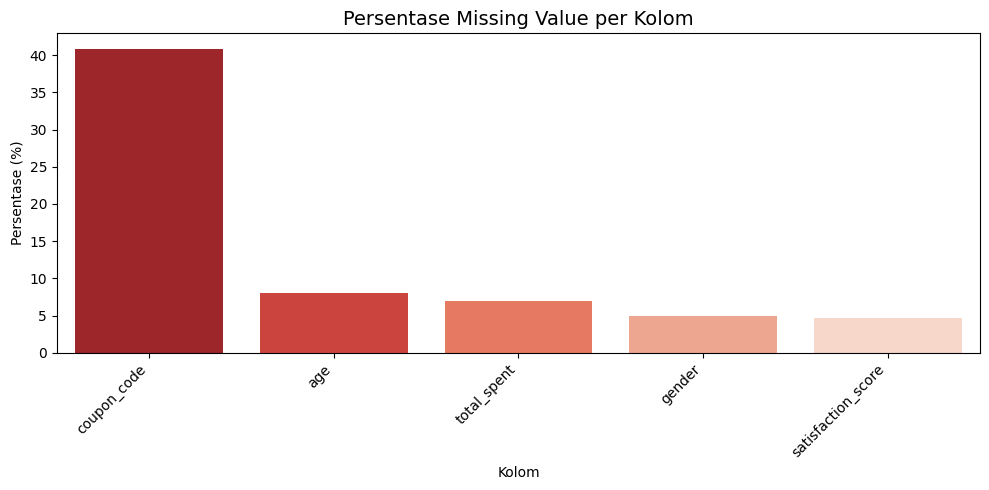

In [ ]:
missing = df_churn.isnull().sum()
missing_pct = (missing / len(df_churn) * 100).round(2)
missing_df = pd.DataFrame ({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0').sort_values('Persentase (%)', ascending=False)

print("Kolom dengan Missing Value:")
print(missing_df)

# visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Persentase (%)'], palette='Reds_r')
plt.title('Persentase Missing Value per Kolom', fontsize=14)
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Distribusi Target (Churn)

Distribusi Churn:
 Tidak Churn (0) : 12,702 (84.7%)
 Churn       (1) : 2,298 (15.3%)


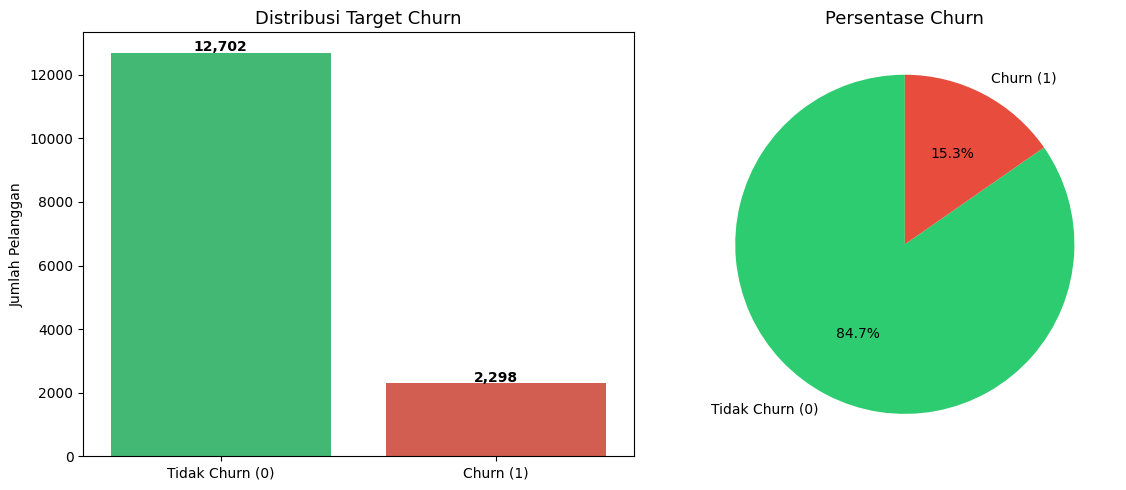

In [ ]:
churn_counts = df_churn['churn'].value_counts()
churn_pct = df_churn['churn'].value_counts(normalize=True) * 100

print("Distribusi Churn:")
print(f" Tidak Churn (0) : {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f" Churn       (1) : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")

# visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.barplot(x=['Tidak Churn (0)', 'Churn (1)'],
              y=churn_counts.values,
              palette=['#2ecc71', '#e74c3c'], # Corrected color code
              ax=axes[0])
axes[0].set_title('Distribusi Target Churn', fontsize=13)
axes[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Tidak Churn (0)', 'Churn (1)'],
            colors=['#2ecc71', '#e74c3c'], # Corrected color code
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Persentase Churn', fontsize=13)

plt.tight_layout()
plt.show()

Heatmap Korelasi

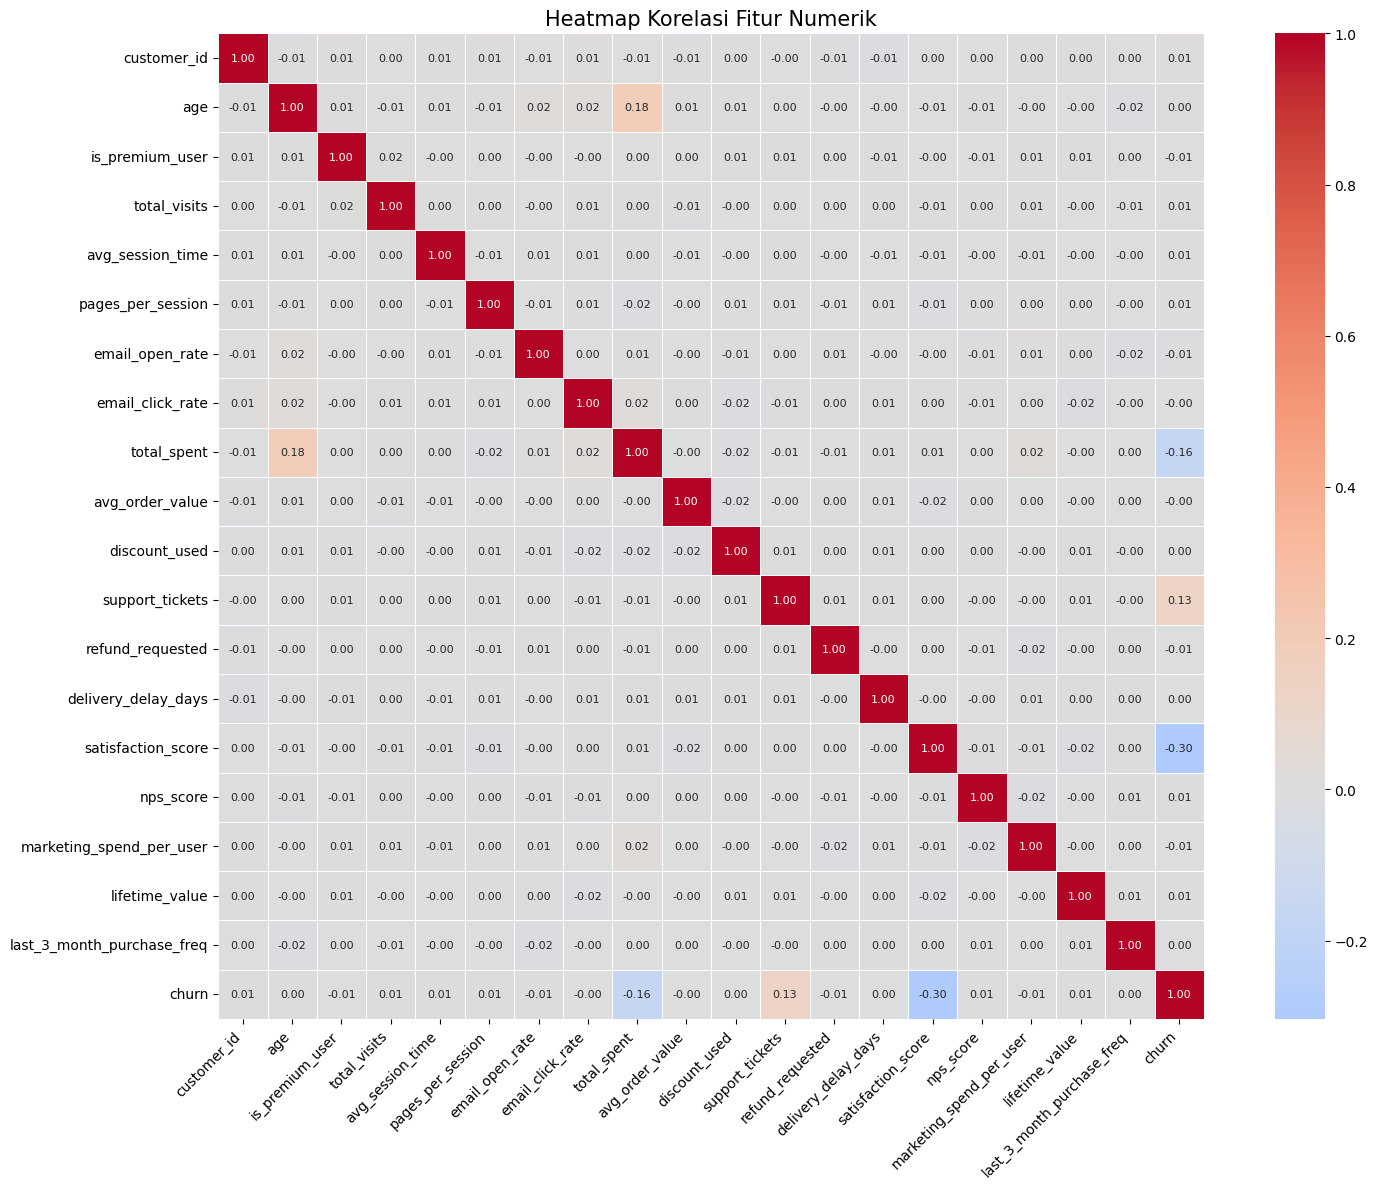


Korelasi fitur terhadap Churn (diurutkan):
churn                         1.000000
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588


In [ ]:
# hanya mengambil kolom numerik
numeric_cols = df_churn.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(16, 12))
corr_matrix = df_churn[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=0.5, annot_kws={'size': 8})

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Tampilkan korelasi tertinggi dengan target churn
print("\nKorelasi fitur terhadap Churn (diurutkan):")
print(corr_matrix['churn'].sort_values(ascending=False).to_string())

## Direct Modeling

Persiapan Data Direct Modeling

In [ ]:
df_direct = df_churn.copy()

X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

print(f"Shape X : {X_direct.shape}")
print(f"Shape Y : {y_direct.shape}")
print(f"\nDistribusi target:\n {y_direct.value_counts()}")

Shape X : (15000, 29)
Shape Y : (15000,)

Distribusi target:
 churn
0    12702
1     2298
Name: count, dtype: int64


Handle Data Agar Bisa Dilatih

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_direct.select_dtypes(include=['object']).columns.tolist()
num_cols = X_direct.select_dtypes(include=[np.number]).columns.tolist()

print(f"Kolom Kategorikal   : {cat_cols}")
print(f"Kolom Numerik     : {num_cols}")

# isi missing value numerik dengan median
for col in num_cols:
    X_direct[col].fillna(X_direct[col].median(), inplace=True)

# isi missing value katgorikal dengan modus
for col in cat_cols:
    X_direct[col].fillna(X_direct[col].mode()[0], inplace=True)

# encode kolom kategorikal dengan OrdinalEncoder (konversi minimal)
oe = OrdinalEncoder()
X_direct[cat_cols] = oe.fit_transform(X_direct[cat_cols])

print(f"\nKonversi minimal selesai !")
print(f"Missing value tersisa : {X_direct.isnull().sum().sum()}")

Kolom Kategorikal   : ['gender', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']
Kolom Numerik     : ['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

Konversi minimal selesai !
Missing value tersisa : 0


Train-Test Split

In [ ]:
X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct, y_direct,
    test_size=0.2,
    random_state=42,
    stratify=y_direct
)

print(f"Data Latih : {X_train_direct.shape[0]:,} baris")
print(f"Data Uji   : {X_test_direct.shape[0]:,} baris")

Data Latih : 12,000 baris
Data Uji   : 3,000 baris


Fungsi Evaluasi

In [ ]:
def evaluasi_model(nama_model, y_true, y_pred):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, zero_division=0)
  rec = recall_score(y_true, y_pred, zero_division=0)
  f1 = f1_score(y_true, y_pred)

  print(f"\n{'='*45}")
  print(f"Evaluasi Model {nama_model}")
  print(f"{'='*45}")
  print(f"Accuracy  : {acc:.4f}")
  print(f"Precision : {prec:.4f}")
  print(f"Recall    : {rec:.4f}")
  print(f"F1-Score  : {f1:.4f}")
  print(f"\n{'='*45}")

  # confusion matrix
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Tidak Churn', 'Churn'])
  disp.plot(cmap='Blues')
  plt.title(f'Confusion Matrix - {nama_model}')
  plt.tight_layout()
  plt.show()

  return {'Model' : nama_model, 'Accuracy' : acc,
          'Precision' : prec, 'Recall' : rec, 'F1-Score' : f1}

Latih & Evaluasi Model

⏳ Melatih logistic regresion...

Evaluasi Model Logistic Regression (Direct)
Accuracy  : 0.8473
Precision : 0.5069
Recall    : 0.1587
F1-Score  : 0.2417



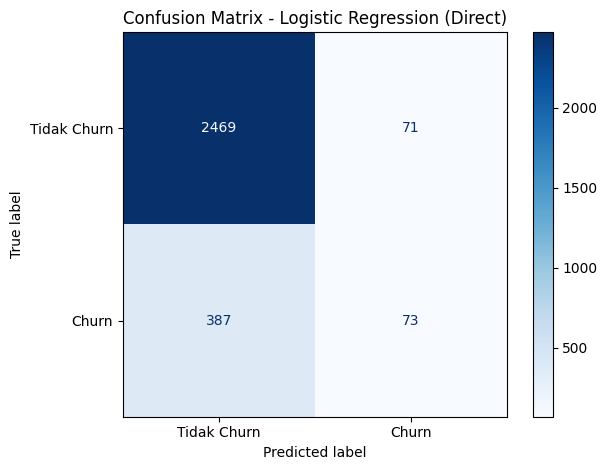

⏳ Melatih Random Forest...

Evaluasi Model Random Forest (Direct)
Accuracy  : 0.8553
Precision : 0.5419
Recall    : 0.3652
F1-Score  : 0.4364



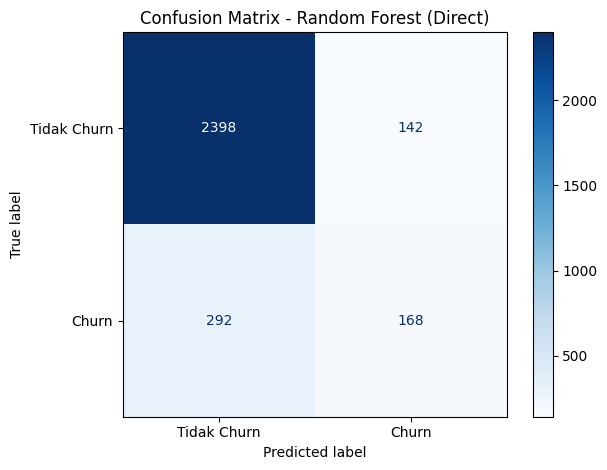

⏳ Melatih Voting Classifier...

Evaluasi Model Voting Classifier (Direct)
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.0065
F1-Score  : 0.0129



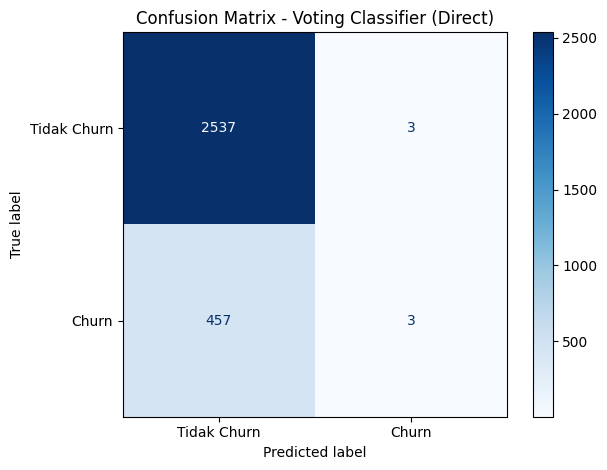

In [ ]:
hasil_direct = []

# Logistic Regression
print("⏳ Melatih logistic regresion...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_direct, y_train_direct)
y_pred_lr = lr.predict(X_test_direct)
hasil_direct.append(evaluasi_model("Logistic Regression (Direct)", y_test_direct, y_pred_lr))

# Random Forest
print("⏳ Melatih Random Forest...")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_direct, y_train_direct)
y_pred_rf = rf.predict(X_test_direct)
hasil_direct.append(evaluasi_model("Random Forest (Direct)", y_test_direct, y_pred_rf))

# Voting Classifier
print("⏳ Melatih Voting Classifier...")
voting = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='soft')
voting.fit(X_train_direct, y_train_direct)
y_pred_voting = voting.predict(X_test_direct)
hasil_direct.append(evaluasi_model("Voting Classifier (Direct)", y_test_direct, y_pred_voting))

Rekap Hasil


REKAP HASIL DIRECT MODELING
                              Accuracy  Precision    Recall  F1-Score
Model                                                                
Logistic Regression (Direct)  0.847333   0.506944  0.158696  0.241722
Random Forest (Direct)        0.855333   0.541935  0.365217  0.436364
Voting Classifier (Direct)    0.846667   0.500000  0.006522  0.012876


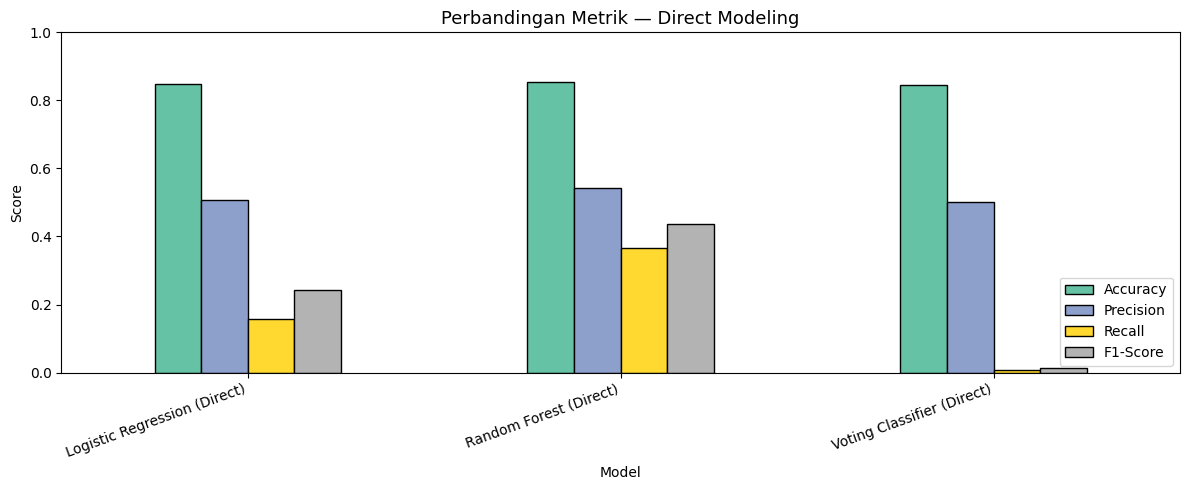

In [ ]:
df_hasil_direct = pd.DataFrame(hasil_direct)
df_hasil_direct = df_hasil_direct.set_index('Model')

print("\nREKAP HASIL DIRECT MODELING")
print(df_hasil_direct.to_string())

# Visualisasi perbandingan
df_hasil_direct.plot(kind='bar', figsize=(12, 5), ylim=(0, 1),
                      colormap='Set2', edgecolor='black')
plt.title('Perbandingan Metrik — Direct Modeling', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Modeling Dengan Preprocessing

copy data bersih

In [ ]:
df_prep = df_churn.copy()

print(f"Shape awal: {df_prep.shape}")
print(f"\nMissing value awal:")
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

Shape awal: (15000, 30)

Missing value awal:
gender                 738
age                   1200
total_spent           1050
coupon_code           6133
satisfaction_score     702
dtype: int64


Handling missing value

In [ ]:
# Drop kolom coupon_code (missing 40.89% — terlalu banyak)
df_prep.drop(columns=['coupon_code'], inplace=True)
print("✅ Kolom coupon_code di-drop")

# Isi missing value numerik dengan median
num_cols_prep = df_prep.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols_prep:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].median(), inplace=True)
        print(f"✅ {col} diisi dengan median")

# Isi missing value kategorikal dengan modus
cat_cols_prep = df_prep.select_dtypes(include='object').columns.tolist()
for col in cat_cols_prep:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)
        print(f"✅ {col} diisi dengan modus")

print(f"\nMissing value tersisa: {df_prep.isnull().sum().sum()}")

✅ Kolom coupon_code di-drop
✅ age diisi dengan median
✅ total_spent diisi dengan median
✅ satisfaction_score diisi dengan median
✅ gender diisi dengan modus

Missing value tersisa: 0


Handling Duplikasi

In [ ]:
duplikat = df_prep.duplicated().sum()
print(f"Jumlah duplikasi: {duplikat}")

if duplikat > 0:
    df_prep.drop_duplicates(inplace=True)
    print(f"✅ Duplikasi dihapus")
else:
    print("✅ Tidak ada duplikasi")

print(f"Shape setelah handling duplikasi: {df_prep.shape}")

Jumlah duplikasi: 0
✅ Tidak ada duplikasi
Shape setelah handling duplikasi: (15000, 29)


Handling Outlier

In [ ]:
# Kolom numerik yang dicek outlier-nya
# (exclude kolom biner dan id)
exclude_cols = ['customer_id', 'is_premium_user', 'discount_used',
                'refund_requested', 'churn']
outlier_cols = [col for col in num_cols_prep if col not in exclude_cols]

print("Jumlah outlier per kolom (sebelum):")
total_outlier = 0
for col in outlier_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier = ((df_prep[col] < Q1 - 1.5*IQR) |
               (df_prep[col] > Q3 + 1.5*IQR)).sum()
    total_outlier += outlier
    if outlier > 0:
        print(f"  {col}: {outlier}")

print(f"\nTotal outlier: {total_outlier}")

# Cap outlier dengan batas IQR (Winsorizing)
for col in outlier_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)

print("\n✅ Outlier sudah di-cap dengan metode Winsorizing")
print(f"Shape setelah handling outlier: {df_prep.shape}")

Jumlah outlier per kolom (sebelum):
  age: 218
  total_visits: 39
  avg_session_time: 45
  pages_per_session: 33
  total_spent: 119
  avg_order_value: 54
  support_tickets: 79
  delivery_delay_days: 184
  satisfaction_score: 753
  lifetime_value: 56

Total outlier: 1580

✅ Outlier sudah di-cap dengan metode Winsorizing
Shape setelah handling outlier: (15000, 29)


Drop fitur tidak relevan & encoding

In [ ]:
# customer_id   : hanya ID unik, tidak informatif
# signup_date   : sudah tidak relevan langsung,
#                 bisa diganti fitur turunan
# last_purchase_date : sama seperti signup_date

df_prep.drop(columns=['customer_id', 'signup_date',
                       'last_purchase_date'], inplace=True)

print(f"✅ Fitur tidak relevan di-drop")
print(f"Shape sekarang: {df_prep.shape}")
print(f"\nKolom tersisa: {df_prep.columns.tolist()}")

✅ Fitur tidak relevan di-drop
Shape sekarang: (15000, 26)

Kolom tersisa: ['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


In [ ]:
# encoding fitur kategorikal
cat_cols_enc = df_prep.select_dtypes(include='object').columns.tolist()
print(f"Kolom yang di-encode: {cat_cols_enc}")

# Label Encoding untuk semua kolom kategorikal
le_dict = {}
for col in cat_cols_enc:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col])
    le_dict[col] = le
    print(f"  ✅ {col} di-encode")

print(f"\nShape setelah encoding: {df_prep.shape}")

Kolom yang di-encode: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']
  ✅ gender di-encode
  ✅ country di-encode
  ✅ city di-encode
  ✅ acquisition_channel di-encode
  ✅ device_type di-encode
  ✅ subscription_type di-encode
  ✅ payment_method di-encode

Shape setelah encoding: (15000, 26)


Split data

In [ ]:
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

# Proporsi sama dengan direct modeling (80:20)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep,
    test_size=0.2,
    random_state=42,
    stratify=y_prep
)

print(f"Data latih : {X_train_p.shape[0]:,} baris")
print(f"Data uji   : {X_test_p.shape[0]:,} baris")

Data latih : 12,000 baris
Data uji   : 3,000 baris


Scalling (setelah split)

In [ ]:
scaler = StandardScaler()

# Fit HANYA pada data latih, transform keduanya
X_train_p_scaled = scaler.fit_transform(X_train_p)
X_test_p_scaled  = scaler.transform(X_test_p)

print("✅ Scaling selesai!")
print(f"Shape X_train : {X_train_p_scaled.shape}")
print(f"Shape X_test  : {X_test_p_scaled.shape}")

✅ Scaling selesai!
Shape X_train : (12000, 25)
Shape X_test  : (3000, 25)


SMOTE (Handle Imbalanced)

In [ ]:
print(f"Distribusi sebelum SMOTE:\n{pd.Series(y_train_p).value_counts()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p_scaled, y_train_p)

print(f"\nDistribusi setelah SMOTE:\n{pd.Series(y_train_sm).value_counts()}")
print(f"\n✅ SMOTE selesai!")
print(f"Shape X_train setelah SMOTE: {X_train_sm.shape}")

Distribusi sebelum SMOTE:
churn
0    10162
1     1838
Name: count, dtype: int64

Distribusi setelah SMOTE:
churn
1    10162
0    10162
Name: count, dtype: int64

✅ SMOTE selesai!
Shape X_train setelah SMOTE: (20324, 25)


Latih & Evaluasi 3 Model

⏳ Melatih Logistic Regression...

Evaluasi Model Logistic Regression (Preprocessing)
Accuracy  : 0.7523
Precision : 0.3499
Recall    : 0.7174
F1-Score  : 0.4704



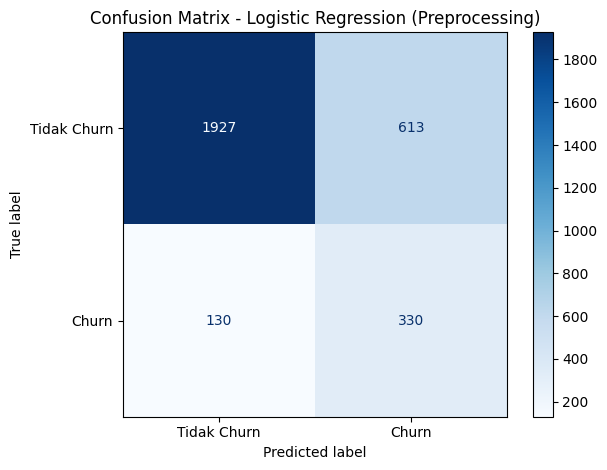

⏳ Melatih Random Forest...

Evaluasi Model Random Forest (Preprocessing)
Accuracy  : 0.8510
Precision : 0.5104
Recall    : 0.6957
F1-Score  : 0.5888



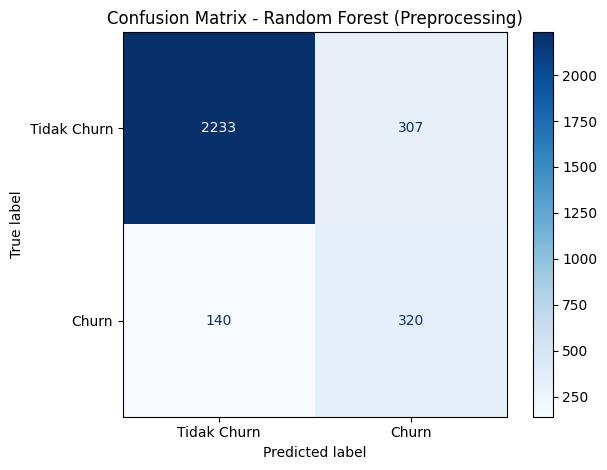

⏳ Melatih Voting Classifier...

Evaluasi Model Voting Classifier (Preprocessing)
Accuracy  : 0.8213
Precision : 0.4465
Recall    : 0.6891
F1-Score  : 0.5419



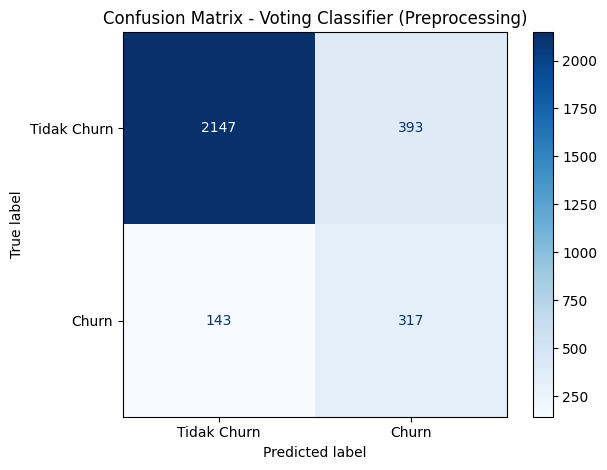

In [ ]:
hasil_prep = []

# --- Model 1: Logistic Regression ---
print("⏳ Melatih Logistic Regression...")
lr_p = LogisticRegression(random_state=42, max_iter=1000)
lr_p.fit(X_train_sm, y_train_sm)
y_pred_lr_p = lr_p.predict(X_test_p_scaled)
hasil_prep.append(evaluasi_model(
    "Logistic Regression (Preprocessing)", y_test_p, y_pred_lr_p))

# --- Model 2: Random Forest ---
print("⏳ Melatih Random Forest...")
rf_p = RandomForestClassifier(random_state=42)
rf_p.fit(X_train_sm, y_train_sm)
y_pred_rf_p = rf_p.predict(X_test_p_scaled)
hasil_prep.append(evaluasi_model(
    "Random Forest (Preprocessing)", y_test_p, y_pred_rf_p))

# --- Model 3: Voting Classifier ---
print("⏳ Melatih Voting Classifier...")
voting_p = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='soft')
voting_p.fit(X_train_sm, y_train_sm)
y_pred_voting_p = voting_p.predict(X_test_p_scaled)
hasil_prep.append(evaluasi_model(
    "Voting Classifier (Preprocessing)", y_test_p, y_pred_voting_p))

Rekap Hasil Preprocessing


📊 REKAP HASIL MODELING DENGAN PREPROCESSING
                                     Accuracy  Precision    Recall  F1-Score
Model                                                                       
Logistic Regression (Preprocessing)  0.752333   0.349947  0.717391  0.470421
Random Forest (Preprocessing)        0.851000   0.510367  0.695652  0.588776
Voting Classifier (Preprocessing)    0.821333   0.446479  0.689130  0.541880


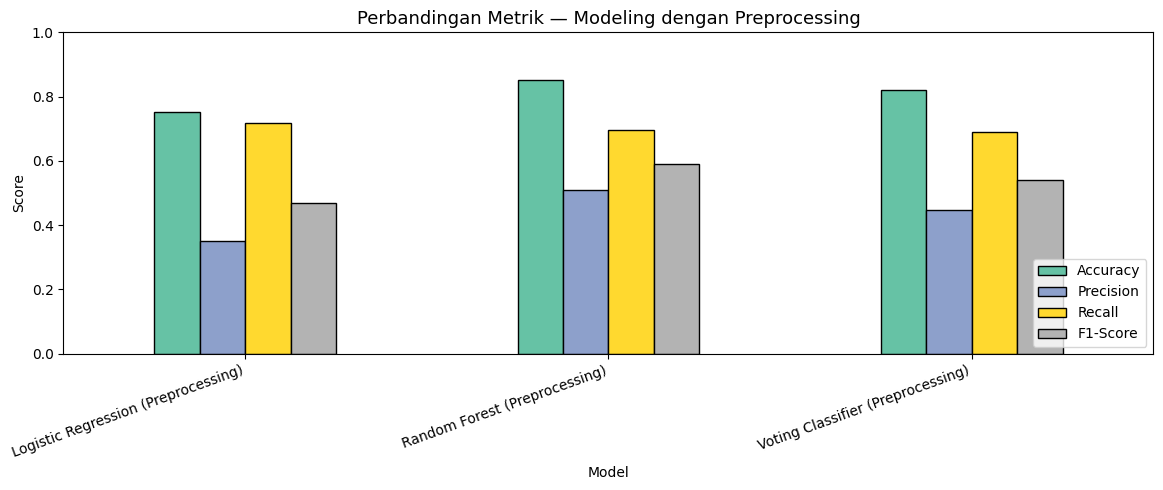

In [ ]:
df_hasil_prep = pd.DataFrame(hasil_prep)
df_hasil_prep = df_hasil_prep.set_index('Model')

print("\n📊 REKAP HASIL MODELING DENGAN PREPROCESSING")
print(df_hasil_prep.to_string())

# Visualisasi
df_hasil_prep.plot(kind='bar', figsize=(12, 5), ylim=(0, 1),
                    colormap='Set2', edgecolor='black')
plt.title('Perbandingan Metrik — Modeling dengan Preprocessing', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning & Feature Selection

Feature Importance Analysis

📊 Feature Importance (Top 15):
                 Feature  Importance
      satisfaction_score    0.280661
             total_spent    0.224251
         support_tickets    0.101565
                 country    0.036474
             device_type    0.032458
          payment_method    0.029181
                    city    0.025288
     acquisition_channel    0.021117
     delivery_delay_days    0.020582
marketing_spend_per_user    0.019724
               nps_score    0.019318
        avg_session_time    0.018699
          lifetime_value    0.018641
        email_click_rate    0.018614
         email_open_rate    0.018126


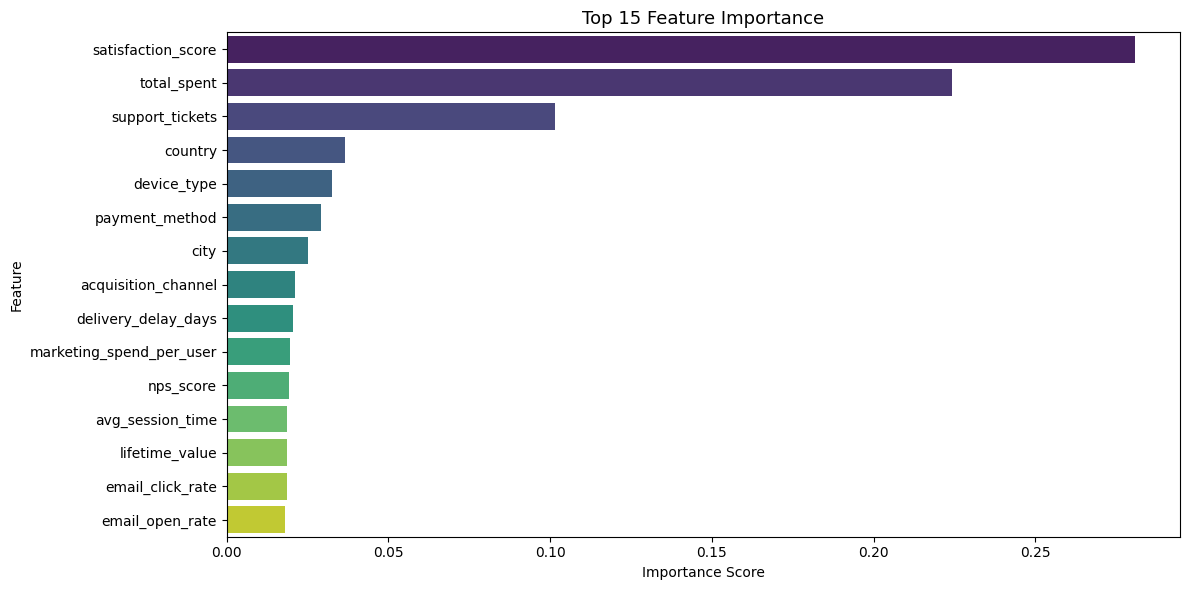

In [ ]:
# menggunakan Random Forest untuk feature importance
rf_fi = RandomForestClassifier(random_state=42)
rf_fi.fit(X_train_sm, y_train_sm)

# Ambil feature importance
feature_names = X_prep.columns.tolist()
importances = rf_fi.feature_importances_
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance (Top 15):")
print(fi_df.head(15).to_string(index=False))

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(data=fi_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Feature Selection

In [ ]:
# Ambil top 15 fitur terpenting
top_features = fi_df.head(15)['Feature'].tolist()
print(f"Top 15 fitur yang dipilih:\n{top_features}")

# Filter dataset hanya pakai top features
X_prep_fs = X_prep[top_features]

# Split ulang dengan fitur terpilih
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_prep_fs, y_prep,
    test_size=0.2,
    random_state=42,
    stratify=y_prep
)

# Scaling
scaler_fs = StandardScaler()
X_train_fs_scaled = scaler_fs.fit_transform(X_train_fs)
X_test_fs_scaled  = scaler_fs.transform(X_test_fs)

# SMOTE
X_train_fs_sm, y_train_fs_sm = smote.fit_resample(X_train_fs_scaled, y_train_fs)

print(f"\n✅ Feature selection selesai!")
print(f"Shape X_train : {X_train_fs_sm.shape}")
print(f"Shape X_test  : {X_test_fs_scaled.shape}")

Top 15 fitur yang dipilih:
['satisfaction_score', 'total_spent', 'support_tickets', 'country', 'device_type', 'payment_method', 'city', 'acquisition_channel', 'delivery_delay_days', 'marketing_spend_per_user', 'nps_score', 'avg_session_time', 'lifetime_value', 'email_click_rate', 'email_open_rate']

✅ Feature selection selesai!
Shape X_train : (20324, 15)
Shape X_test  : (3000, 15)


Tuning Logistic Regression

In [ ]:
# TUNING LOGISTIC REGRESSION
print("⏳ Tuning Logistic Regression...")

param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

gs_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_lr,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
gs_lr.fit(X_train_fs_sm, y_train_fs_sm)

print(f"✅ Best params LR : {gs_lr.best_params_}")
print(f"   Best F1 score  : {gs_lr.best_score_:.4f}")

⏳ Tuning Logistic Regression...
✅ Best params LR : {'solver': 'liblinear', 'max_iter': 500, 'C': 0.01}
   Best F1 score  : 0.7771


In [ ]:
# TUNING RANDOM FOREST
print("⏳ Tuning Random Forest...")

param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

gs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
gs_rf.fit(X_train_fs_sm, y_train_fs_sm)

print(f"✅ Best params RF : {gs_rf.best_params_}")
print(f"   Best F1 score  : {gs_rf.best_score_:.4f}")

⏳ Tuning Random Forest...
✅ Best params RF : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
   Best F1 score  : 0.9109


In [ ]:
# TUNING VOTING CLASSIFIER
print("⏳ Tuning Voting Classifier...")

# Tuning komponen LR dalam Voting
param_voting = {
    'lr__C': [0.1, 1, 10],
    'lr__max_iter': [500, 1000],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

voting_tune = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='soft')

gs_voting = RandomizedSearchCV(
    voting_tune,
    param_distributions=param_voting,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
gs_voting.fit(X_train_fs_sm, y_train_fs_sm)

print(f"✅ Best params Voting : {gs_voting.best_params_}")
print(f"   Best F1 score      : {gs_voting.best_score_:.4f}")

⏳ Tuning Voting Classifier...
✅ Best params Voting : {'lr__max_iter': 500, 'lr__C': 1, 'knn__weights': 'distance', 'knn__n_neighbors': 3}
   Best F1 score      : 0.9211


Evaluasi Model Setelah Tuning


Evaluasi Model Logistic Regression (Tuned)
Accuracy  : 0.7537
Precision : 0.3545
Recall    : 0.7391
F1-Score  : 0.4792



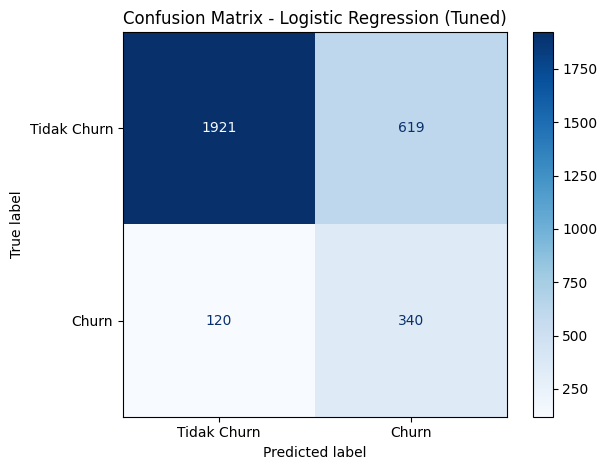


Evaluasi Model Random Forest (Tuned)
Accuracy  : 0.8547
Precision : 0.5141
Recall    : 0.9500
F1-Score  : 0.6672



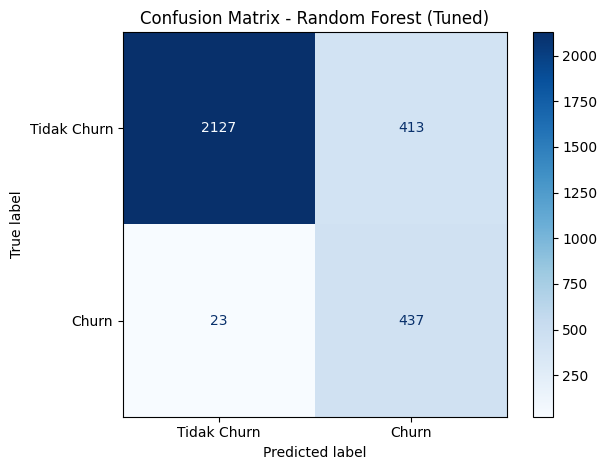


Evaluasi Model Voting Classifier (Tuned)
Accuracy  : 0.8233
Precision : 0.4515
Recall    : 0.7087
F1-Score  : 0.5516



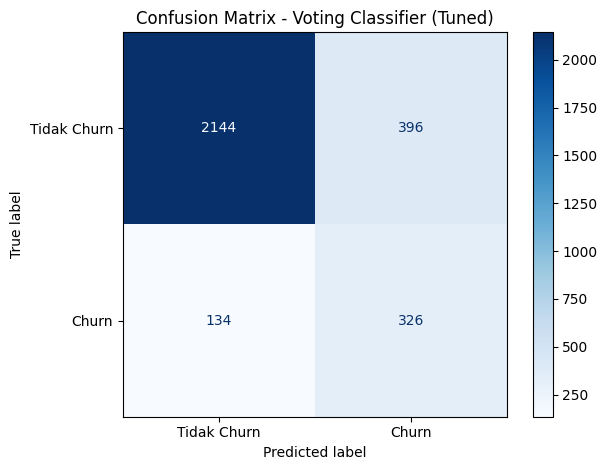

In [ ]:
hasil_tuning = []

# Logistic Regression Tuned
y_pred_lr_t = gs_lr.best_estimator_.predict(X_test_fs_scaled)
hasil_tuning.append(evaluasi_model(
    "Logistic Regression (Tuned)", y_test_fs, y_pred_lr_t))

# Random Forest Tuned
y_pred_rf_t = gs_rf.best_estimator_.predict(X_test_fs_scaled)
hasil_tuning.append(evaluasi_model(
    "Random Forest (Tuned)", y_test_fs, y_pred_rf_t))

# Voting Classifier Tuned
y_pred_voting_t = gs_voting.best_estimator_.predict(X_test_fs_scaled)
hasil_tuning.append(evaluasi_model(
    "Voting Classifier (Tuned)", y_test_fs, y_pred_voting_t))

Rekap & Perbandingan Semua Skenario


📊 REKAP HASIL HYPERPARAMETER TUNING
                             Accuracy  Precision    Recall  F1-Score
Model                                                               
Logistic Regression (Tuned)  0.753667   0.354536  0.739130  0.479211
Random Forest (Tuned)        0.854667   0.514118  0.950000  0.667176
Voting Classifier (Tuned)    0.823333   0.451524  0.708696  0.551607

📊 REKAP SEMUA SKENARIO
                                     Accuracy  Precision    Recall  F1-Score
Model                                                                       
Logistic Regression (Direct)         0.847333   0.506944  0.158696  0.241722
Random Forest (Direct)               0.855333   0.541935  0.365217  0.436364
Voting Classifier (Direct)           0.846667   0.500000  0.006522  0.012876
Logistic Regression (Preprocessing)  0.752333   0.349947  0.717391  0.470421
Random Forest (Preprocessing)        0.851000   0.510367  0.695652  0.588776
Voting Classifier (Preprocessing)    0.821333   0.44647

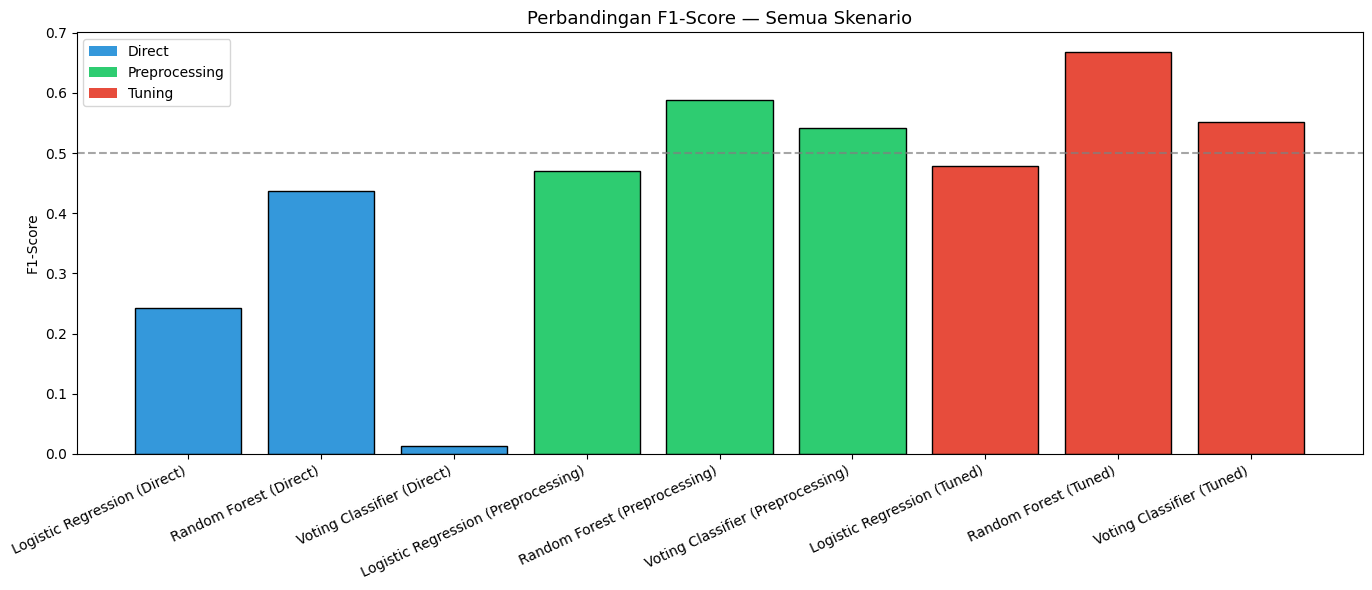

In [ ]:
df_hasil_tuning = pd.DataFrame(hasil_tuning).set_index('Model')

print("\n📊 REKAP HASIL HYPERPARAMETER TUNING")
print(df_hasil_tuning.to_string())

# Gabungkan semua hasil
df_all = pd.concat([df_hasil_direct, df_hasil_prep, df_hasil_tuning])

print("\n📊 REKAP SEMUA SKENARIO")
print(df_all.to_string())

# Visualisasi F1-Score semua skenario
plt.figure(figsize=(14, 6))
colors = ['#3498db']*3 + ['#2ecc71']*3 + ['#e74c3c']*3
plt.bar(range(len(df_all)), df_all['F1-Score'], color=colors, edgecolor='black')
plt.xticks(range(len(df_all)), df_all.index, rotation=25, ha='right')
plt.ylabel('F1-Score')
plt.title('Perbandingan F1-Score — Semua Skenario', fontsize=13)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold 0.5')

# Legend skenario
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Direct'),
    Patch(facecolor='#2ecc71', label='Preprocessing'),
    Patch(facecolor='#e74c3c', label='Tuning')
]
plt.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

SIMPAN MODEL TERBAIK

In [ ]:
import joblib

# Simpan model terbaik (Random Forest Tuned)
joblib.dump(gs_rf.best_estimator_, 'model_churn.pkl')

# Simpan scaler
joblib.dump(scaler_fs, 'scaler.pkl')

# Simpan label encoder
joblib.dump(le_dict, 'label_encoders.pkl')

# Simpan daftar top features
import json
with open('top_features.json', 'w') as f:
    json.dump(top_features, f)

print("✅ Model, scaler, encoder, dan fitur berhasil disimpan!")
print(f"Top features: {top_features}")

# Download semua file
from google.colab import files
files.download('model_churn.pkl')
files.download('scaler.pkl')
files.download('label_encoders.pkl')
files.download('top_features.json')

✅ Model, scaler, encoder, dan fitur berhasil disimpan!
Top features: ['satisfaction_score', 'total_spent', 'support_tickets', 'country', 'device_type', 'payment_method', 'city', 'acquisition_channel', 'delivery_delay_days', 'marketing_spend_per_user', 'nps_score', 'avg_session_time', 'lifetime_value', 'email_click_rate', 'email_open_rate']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RINGKASAN AKHIR


In [1]:
print("=" * 60)
print("RINGKASAN PROYEK UAS BENGKEL KODING DATA SCIENCE")
print("=" * 60)
print(f"\nDataset     : Sales and Marketing Customer (15.000 records)")
print(f"Target      : Churn Prediction (Binary Classification)")
print(f"\nModel Terbaik : Random Forest (Hyperparameter Tuned)")
print(f"Accuracy      : 0.8547")
print(f"Precision     : 0.5141")
print(f"Recall        : 0.9500")
print(f"F1-Score      : 0.6672")

print(f"\nLink GitHub   : https://github.com/ghaitsafiya/churn-prediction-app")
print(f"Link Streamlit: https://churn-prediction-app-4ypdyh6o23ny45i2ebmars.streamlit.app/")

RINGKASAN PROYEK UAS BENGKEL KODING DATA SCIENCE

Dataset     : Sales and Marketing Customer (15.000 records)
Target      : Churn Prediction (Binary Classification)

Model Terbaik : Random Forest (Hyperparameter Tuned)
Accuracy      : 0.8547
Precision     : 0.5141
Recall        : 0.9500
F1-Score      : 0.6672

Link GitHub   : https://github.com/ghaitsafiya/churn-prediction-app
Link Streamlit: https://churn-prediction-app-4ypdyh6o23ny45i2ebmars.streamlit.app/
